In [1]:
import numpy as np
import json
import tamubo.exactbo as ebo

In [5]:
log_numpy_path = "logs/numpy_trial.json"

with open(log_numpy_path, 'r') as f:
    data = json.load(f)

def objective(X):
    if len(X.shape) == 1:
        X = X.reshape(1,-1)

    x, y = X[:,0], X[:,1]

    # Parameters
    alpha = 0.1
    A  = np.array([4, 3, 2])
    B  = np.array([0.08, 0.05, 0.02])    # betas
    C  = np.array([[0.9, 0.3 ],      # centers (x1,y1)
                [0.1 , 0.8],
                [0.6 , 0.7 ]])
    D = 2
    
    # Compute function value
    val = alpha*(x**2 + y**2)
    for Ai, Bi, (xi, yi) in zip(A, B, C):
        r2 = (x - xi)**2 + (y - yi)**2
        val -= Ai * np.exp(-r2 / Bi)
    val += D
    return val

BOUNDS = np.array([[0.0, 1.0], [0.0, 1.0]], dtype=float)

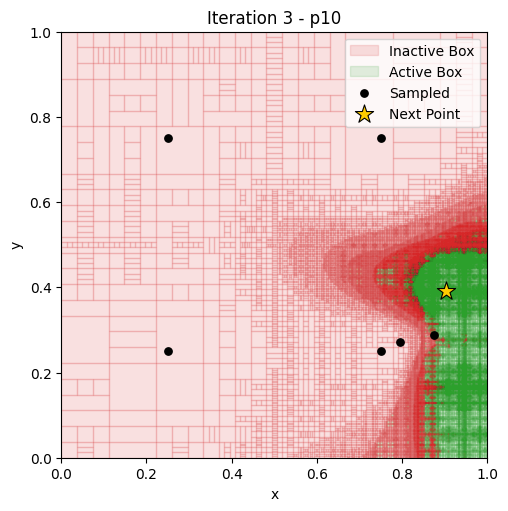

<Axes: title={'center': 'Iteration 3 - p10'}, xlabel='x', ylabel='y'>

In [19]:
ebo.plot_log(data, 2, 10)

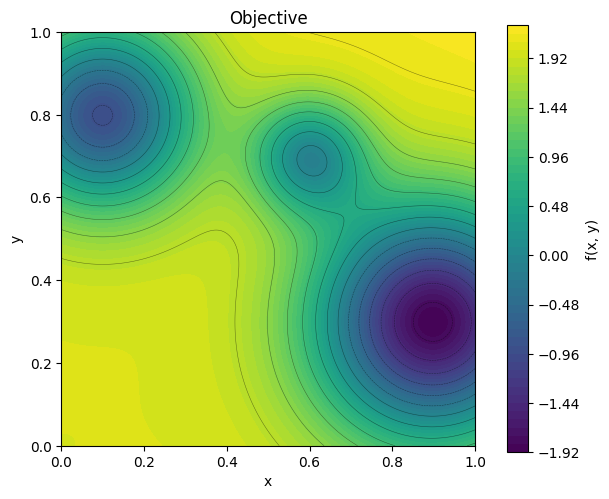

<Axes: title={'center': 'Objective'}, xlabel='x', ylabel='y'>

In [12]:
ebo.plot_f(objective, BOUNDS)